In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk import tokenize
import os
import asyncpg
from dotenv import load_dotenv
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse
from tqdm import tqdm
import numpy as np
import pandas as pd

print(load_dotenv())

# Ensure python (*.py) files are reloaded correctly while editing them
%load_ext autoreload
%autoreload 2

DATA_DIR = './data'
OUTPUT_DIR = './data'

True


In [ ]:
comment_df = pd.read_parquet(f'{DATA_DIR}/comments.parquet')
comment_df = comment_df.iloc[4000:, :]  # we leave out the samples used in training the model for fair comparison

In [185]:
event_df = pd.read_parquet(f'{DATA_DIR}/events.parquet')
market_df = pd.read_parquet(f'{DATA_DIR}/markets.parquet')

# VADER

In [71]:
analyzer = SentimentIntensityAnalyzer()
analyzer.polarity_scores("This is a test comment.")



def vader_score_comment_sentiment(comment):
    sentences = tokenize.sent_tokenize(comment)
    sentiments = [analyzer.polarity_scores(s) for s in sentences]
    mean_neg = np.mean([s['neg'] for s in sentiments])
    mean_neu = np.mean([s['neu'] for s in sentiments])
    mean_pos = np.mean([s['pos'] for s in sentiments])
    mean_compound = np.mean([s['compound'] for s in sentiments])
    return mean_neg, mean_neu, mean_pos, mean_compound


# apply sentiment scoring to all comments
mean_neg, mean_neu, mean_pos, mean_compound = zip(*tqdm(comment_df['body'].apply(vader_score_comment_sentiment)))
comment_df['vader_sentiment_neg'] = mean_neg
comment_df['vader_sentiment_neu'] = mean_neu
comment_df['vader_sentiment_pos'] = mean_pos
comment_df['vader_sentiment_compound'] = mean_compound

100%|██████████| 90565/90565 [00:00<00:00, 5791299.75it/s]


In [186]:
# calculate average sentiment per event
def aggregate_sentiment_score(df: pd.DataFrame, comments_df: pd.DataFrame, merge_key) -> pd.DataFrame:
    columns = ['vader_sentiment_neg', 'vader_sentiment_neu', 'vader_sentiment_pos', 'vader_sentiment_compound']
    event_sentiment = comments_df.groupby('parentEntityID')[columns].mean()
    df = df.merge(event_sentiment, left_on=merge_key, right_index=True, how='left')
    df.dropna(subset=columns, inplace=True)
    return df


def calculate_sentiment_label(row):
    if row['vader_sentiment_compound'] >= 0.05:
        return 2  # Positive
    elif row['vader_sentiment_compound'] <= -0.05:
        return 0  # Negative
    else:
        return 1  # Neutral

event_df = aggregate_sentiment_score(event_df, comment_df, 'id')
market_df = aggregate_sentiment_score(market_df, comment_df, 'event_id')
event_df['vader_label'] = event_df.apply(calculate_sentiment_label, axis=1)
market_df['vader_label'] = market_df.apply(calculate_sentiment_label, axis=1)

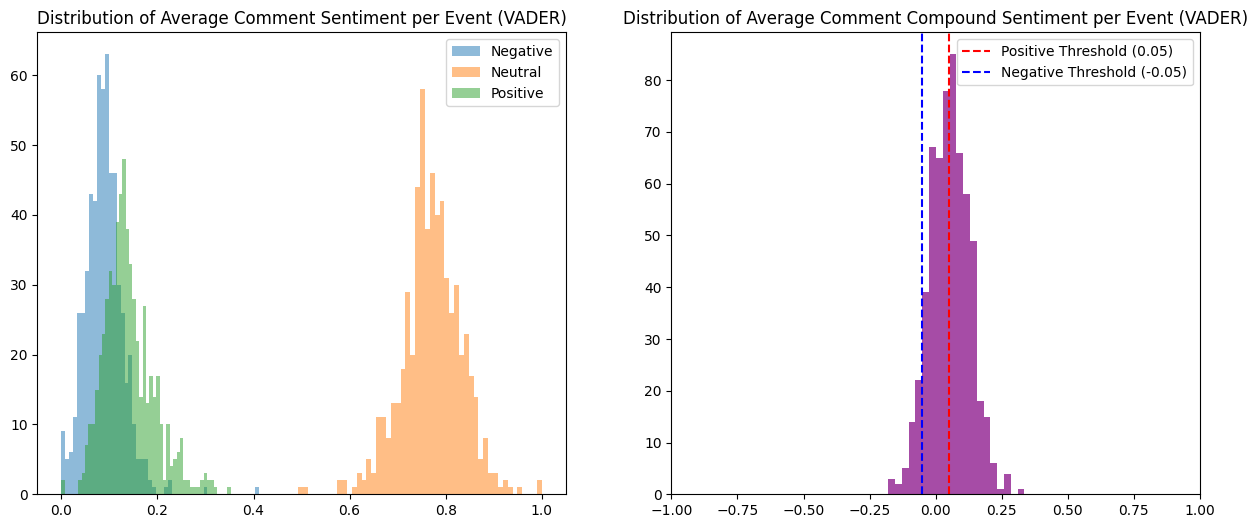

In [83]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(15, 6))


ax[0].hist(event_df['vader_sentiment_neg'], bins=50, alpha=0.5, label='Negative')
ax[0].hist(event_df['vader_sentiment_neu'], bins=50, alpha=0.5, label='Neutral')
ax[0].hist(event_df['vader_sentiment_pos'], bins=50, alpha=0.5, label='Positive')
ax[0].set_title('Distribution of Average Comment Sentiment per Event (VADER)')
ax[0].legend()

ax[1].hist(event_df['vader_sentiment_compound'], bins=20, alpha=0.7, color='purple')
ax[1].axvline(x=0.05, color='red', linestyle='--', label='Positive Threshold (0.05)')
ax[1].axvline(x=-0.05, color='blue', linestyle='--', label='Negative Threshold (-0.05)')
ax[1].set_xlim(-1, 1)
ax[1].set_title('Distribution of Average Comment Compound Sentiment per Event (VADER)')
ax[1].legend()
plt.show()

----

# RoBERTa

In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel, PeftConfig

base_model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=3, return_dict=True)
model = PeftModel.from_pretrained(base_model, "levente-murgas/roberta-polymarket-sentiment-lora-context-gemini-distilled")
tokenizer = AutoTokenizer.from_pretrained("levente-murgas/roberta-polymarket-sentiment-lora-context-gemini-distilled")

# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# --- Your Prediction Function (Unchanged logic) ---
def predict_comment(title, description, comment, max_len=128):
    context_text = f"{title} - {description}"
    
    encoding = tokenizer(
        context_text,
        comment,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    
    # NOW this will work because the model has the classification head
    logits = outputs.logits 
    probabilities = torch.softmax(logits, dim=1)
    predicted_class_id = torch.argmax(probabilities, dim=1).item()
    
    return predicted_class_id, probabilities[0].tolist()

# --- Test ---
t = "System Crash"
d = "The server becomes unresponsive after midnight."
c = "Have you checked the cron jobs?"

label, probs = predict_comment(t, d, c)

print(f"Predicted Label: {label}")
print(f"Probabilities: {probs}")

def score_comment_sentiment(row):
    title = row['event_title']
    description = row['event_desc']
    comment = row['body']
    
    _, probs = predict_comment(title, description, comment)
    # probs is a list of probabilities for each class [neg, neu, pos]
    return probs[0], probs[1], probs[2]  # neg, neu, pos


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Predicted Label: 1
Probabilities: [0.06868071854114532, 0.8077527284622192, 0.1235666573047638]


In [ ]:

# apply sentiment scoring to all comments
mean_neg, mean_neu, mean_pos = zip(*tqdm(comment_df.apply(score_comment_sentiment, axis=1)))
comment_df['roberta_sentiment_neg'] = mean_neg
comment_df['roberta_sentiment_neu'] = mean_neu
comment_df['roberta_sentiment_pos'] = mean_pos

In [187]:
roberta_sentiments = pd.read_parquet(f'./roberta/data/comments_with_sentiment.parquet')
roberta_sentiments.head()
roberta_sentiments.rename(columns={'sentiment_neg': 'roberta_sentiment_neg', 'sentiment_neu': 'roberta_sentiment_neu', 'sentiment_pos': 'roberta_sentiment_pos'}, inplace=True)
roberta_sentiments['roberta_sentiment'] = roberta_sentiments[['roberta_sentiment_neg', 'roberta_sentiment_neu', 'roberta_sentiment_pos']].idxmax(axis=1)

label2num = {'roberta_sentiment_neg': 0, 'roberta_sentiment_neu': 1, 'roberta_sentiment_pos': 2}
roberta_sentiments['roberta_sentiment_label'] = roberta_sentiments['roberta_sentiment'].map(label2num)

def yes_no_ratio(df: pd.DataFrame, comment_df: pd.DataFrame, groupby_col, merge_col) -> pd.DataFrame:
    # count the labels grouped by parentEntityID
    label_counts = comment_df.groupby(groupby_col)['roberta_sentiment_label'].value_counts().unstack(fill_value=0)
    pos = label_counts.get(2, pd.Series(0, index=label_counts.index))
    neg = label_counts.get(0, pd.Series(0, index=label_counts.index))

    # define yes to no ratio as
    # yes_no_ratio = positive_count / positive_count + negative_count + epsilon

    epsilon = 1e-6
    ratio = pos / (pos + neg + epsilon)
    df = df.merge(ratio.rename('roberta_yes_no_ratio'), left_on=merge_col, right_index=True, how='left')
    df.dropna(subset=['roberta_yes_no_ratio'], inplace=True)
    return df


event_df = yes_no_ratio(event_df, roberta_sentiments, 'event_id', 'id')
market_df = yes_no_ratio(market_df, roberta_sentiments, 'market_id', 'id')
event_df.shape, market_df.shape

((598, 82), (598, 94))

# Evaluating predictive power of sentiment score 

In [168]:
def get_event_label(event_id):
    event_markets = market_df[market_df['event_id'] == event_id]

    if event_markets.empty:
        return None
    
    event_markets.loc[:, 'volume'] = pd.to_numeric(event_markets['volume'], errors='coerce').fillna(0)
    
    max_volume_market = event_markets.loc[event_markets['volume'].idxmax()]
    return max_volume_market['label']

event_df.loc[:, 'label'] = event_df['id'].apply(get_event_label)
event_df.shape

(598, 83)

Mean optimal threshold for VADER: 0.4759738261521658
Mean optimal threshold for RoBERTa: 0.4846772096710562


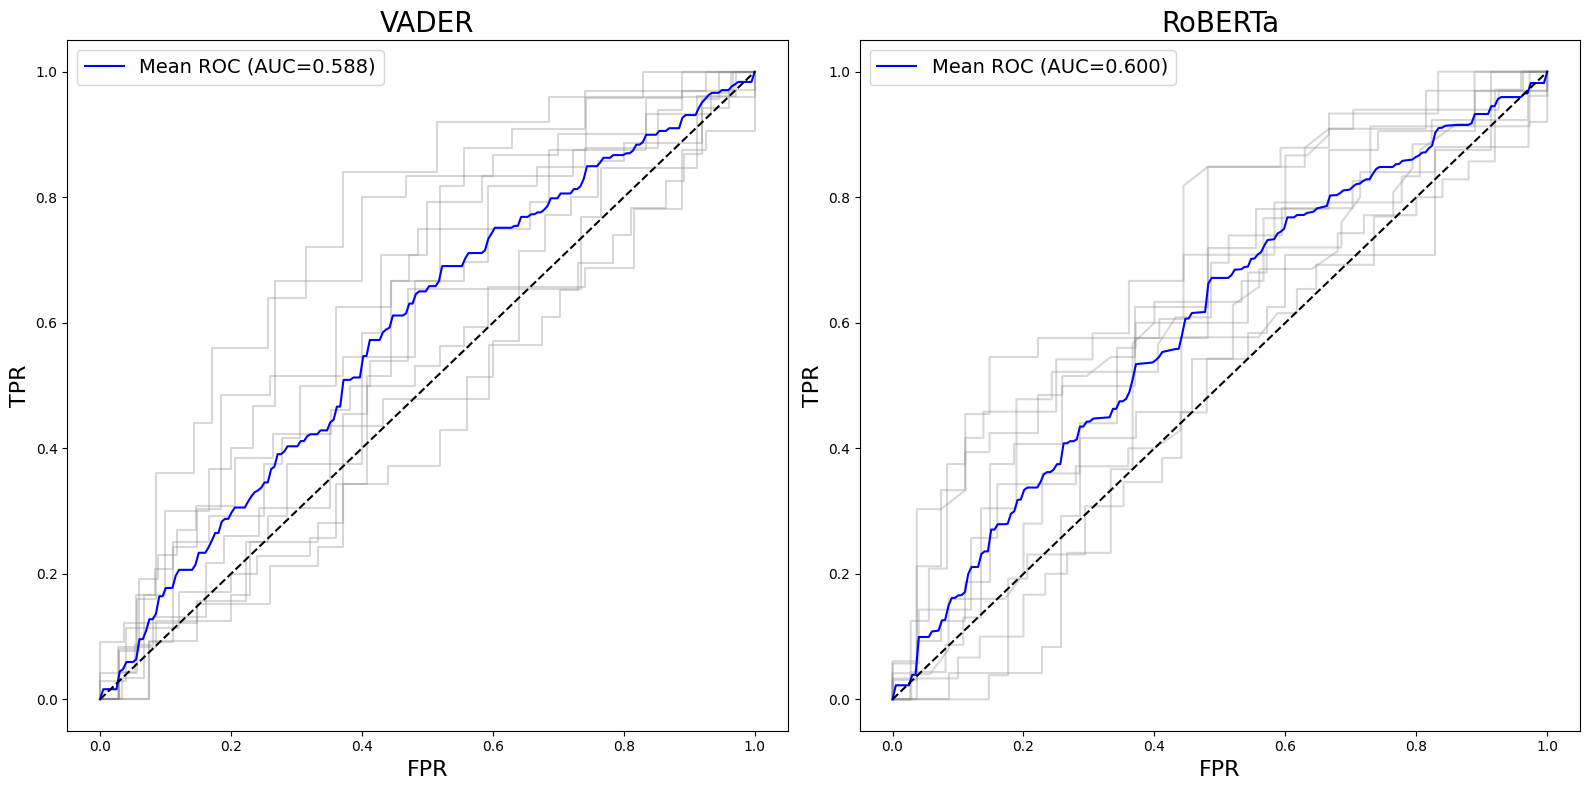

In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc


models_to_features = {
    'VADER': ['vader_sentiment_neg', 'vader_sentiment_pos'],
    'RoBERTa': ['roberta_yes_no_ratio']
} 

def cross_validate(model_name):
    features = models_to_features[model_name]
    X = market_df[features]

    y = market_df['label']

    # Pipeline: scaling + logistic regression
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression())
    ])

    # Outer and inner folds
    outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

    mean_fpr = np.linspace(0, 1, 200)

    fprs = []
    tprs_interp = []
    tprs = []
    aucs = []
    opt_thresholds = []

    all_y_true = []
    all_y_preds_binary = []

    # ------------------------
    # OUTER LOOP
    # ------------------------
    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):

        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

        # ----------------------------------------
        # INNER LOOP: Select optimal threshold
        # ----------------------------------------
        best_thresh = None
        best_j = -np.inf

        for inner_train, inner_val in inner_cv.split(X_train, y_train):
            pipeline.fit(X_train.iloc[inner_train], y_train.iloc[inner_train])
            y_val_probs = pipeline.predict_proba(X_train.iloc[inner_val])[:, 1]

            fpr, tpr, thresholds = roc_curve(y_train.iloc[inner_val], y_val_probs)

            # Youden J = sensitivity + specificity - 1
            J = tpr - fpr
            idx = np.argmax(J)

            if J[idx] > best_j:
                best_j = J[idx]
                best_thresh = thresholds[idx]

        opt_thresholds.append(best_thresh)

        # ----------------------------------------
        # Train final model on full outer training fold
        # ----------------------------------------
        pipeline.fit(X_train, y_train)
        y_probs = pipeline.predict_proba(X_test)[:, 1]

        # Apply the optimal threshold found in the inner loop
        y_pred_bin = (y_probs >= best_thresh).astype(int)

        all_y_true.extend(y_test)
        all_y_preds_binary.extend(y_pred_bin)

        # ROC for this fold
        fpr, tpr, _ = roc_curve(y_test, y_probs)

        # Interpolated TPR for mean ROC curve
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0

        fprs.append(fpr)
        tprs.append(tpr)
        tprs_interp.append(tpr_interp)
        aucs.append(auc(fpr, tpr))

    return all_y_true, all_y_preds_binary, fprs, tprs, tprs_interp, mean_fpr, opt_thresholds

def plot_mean_roc(ax, fprs, tprs, tprs_interp, mean_fpr, model_name):
    for fpr, tpr in zip(fprs, tprs):
        ax.plot(fpr, tpr, color='gray', alpha=0.3)
    
    mean_tpr = np.mean(tprs_interp, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)

    ax.plot(mean_fpr, mean_tpr, color='blue', label=f"Mean ROC (AUC={mean_auc:.3f})")
    ax.plot([0, 1], [0, 1], linestyle='--', color='black')

    ax.set_xlabel("FPR", fontsize=16)
    ax.set_ylabel("TPR", fontsize=16)
    ax.set_title(f"{model_name}", fontsize=20)
    ax.legend(fontsize=14)

def main():
    fig, axs = plt.subplots(1,2,figsize=(16, 8))
    preds = {}
    for ax, model_name in zip(axs, models_to_features.keys()):
        all_y_true, all_y_preds_binary, fprs, tprs, tprs_interp, mean_fpr, opt_thresholds = cross_validate(model_name)
        preds[model_name] = (all_y_true, all_y_preds_binary)
        print(f"Mean optimal threshold for {model_name}: {np.mean(opt_thresholds)}")
        plot_mean_roc(ax, fprs, tprs, tprs_interp, mean_fpr, model_name)

    fig.tight_layout()
    fig.savefig(f'{OUTPUT_DIR}/roc_curves.png')
    return preds

preds = main()

# Statistical significance analysis of the correlation

In [189]:
import statsmodels.api as sm


def logistic_regression_analysis(model_name, market_df):
    # 1. Prepare the data
    # Assuming 'bullish_ratio' is the feature you calculated in your method
    # If you haven't calculated it yet, compute it from your sentiment columns
    features = models_to_features[model_name]
    X_stat = market_df[features]
    y_stat = market_df['label']

    # 2. Add a constant (intercept) term—statsmodels requires this explicitly
    X_stat = sm.add_constant(X_stat)

    # 3. Fit the Logistic Regression (Logit) model
    model = sm.Logit(y_stat, X_stat)
    result = model.fit()

    # 4. Print the summary
    print(result.summary())
    # INTERPRETATION:
    # Look at the 'P>|z|' column for your feature variable.
    # If p < 0.05, the correlation is statistically significant.

logistic_regression_analysis('VADER', market_df)

Optimization terminated successfully.
         Current function value: 0.683006
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                  598
Model:                          Logit   Df Residuals:                      595
Method:                           MLE   Df Model:                            2
Date:                Sat, 29 Nov 2025   Pseudo R-squ.:                 0.01307
Time:                        13:10:55   Log-Likelihood:                -408.44
converged:                       True   LL-Null:                       -413.85
Covariance Type:            nonrobust   LLR p-value:                  0.004476
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.1119      0.327     -3.401      0.001      -1.753      -0.471
va

In [190]:
logistic_regression_analysis('RoBERTa', market_df)

Optimization terminated successfully.
         Current function value: 0.683081
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                  598
Model:                          Logit   Df Residuals:                      596
Method:                           MLE   Df Model:                            1
Date:                Sat, 29 Nov 2025   Pseudo R-squ.:                 0.01296
Time:                        13:10:59   Log-Likelihood:                -408.48
converged:                       True   LL-Null:                       -413.85
Covariance Type:            nonrobust   LLR p-value:                  0.001055
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.7159      0.264      2.714      0.007       0.199       1.233

# McNemar's Test

In [191]:
from statsmodels.stats.contingency_tables import mcnemar

# Ensure inputs are numpy arrays
y_true = np.array(preds['VADER'][0])  # True labels
y_model1 = np.array(preds['VADER'][1])   # e.g., VADER
y_model2 = np.array(preds['RoBERTa'][1]) # e.g., RoBERTa

# Identify correct/incorrect predictions
m1_correct = (y_model1 == y_true)
m2_correct = (y_model2 == y_true)

# Build the 2x2 Contingency Table
#               Model 2 Correct   Model 2 Wrong
# Model 1 Correct      A                B
# Model 1 Wrong        C                D

a = np.sum(m1_correct & m2_correct) # Both correct
b = np.sum(m1_correct & ~m2_correct) # M1 correct, M2 wrong
c = np.sum(~m1_correct & m2_correct) # M1 wrong, M2 correct
d = np.sum(~m1_correct & ~m2_correct) # Both wrong

table = [[a, b], 
         [c, d]]

print("Contingency Table:")
print(table)

# Run the test
# 'exact=True' is recommended if any cell count is < 25
result = mcnemar(table, exact=True)

print(f"\nMcNemar's Test p-value: {result.pvalue:.5f}")

# INTERPRETATION:
# If p < 0.05, there is a significant difference in performance between the two models.

Contingency Table:
[[197, 138], [136, 127]]

McNemar's Test p-value: 0.95184
